<a href="https://colab.research.google.com/github/mcnica89/DATA6100/blob/main/Bootstrap_for_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bootstrap vs Std Dev for means

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Mean of 100 standard Gaussian random variables
-----Theory-----
Stf Dev is 0.1
95% CI is -0.196 to 0.196
95% CI width 0.392
-----Simulations using 100000 indep samples-----
95% CI is -0.196 to 0.196
95% CI width 0.392


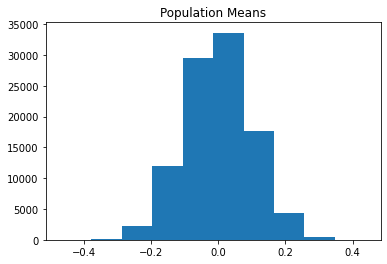

-----Bootstrap Using 1 sample-----
Sample Mean is 0.036
95% CI is -0.157 to 0.231
95% CI width 0.388


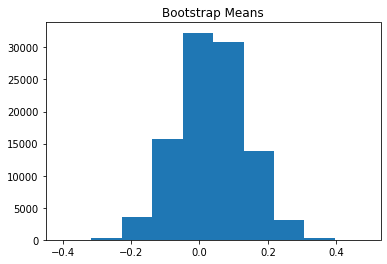

In [24]:
def population_sample(N_samples,N):
  return np.random.randn(N_samples,N)

def bootstrap_sample(X,N_samples):
  N = len(X)
  ix = np.random.randint(0,N,(N,N_samples))
  ans = np.take_along_axis(X[:,np.newaxis],ix,0)
  return ans.T

def plot_and_CI(Xs, my_label):
  means = np.mean(Xs,axis=1)
  sort_means = np.sort(means)
  CI_up = sort_means[int(N_samples*0.975)]
  CI_low = sort_means[int(N_samples*0.025)]
  print(f"95% CI is {CI_low:.3f} to {CI_up:.3f}")
  print(f"95% CI width {CI_up - CI_low:.3f}")

  plt.hist(means)
  plt.title(my_label)
  plt.show()


N = 100
N_samples = 100000

print("===============================================")
print(f"Mean of {N} standard Gaussian random variables")
print("===============================================")

print("-----Theory-----")
print(f"Stf Dev is {1/np.sqrt(N)}")
print(f"95% CI is {-1.96/np.sqrt(N):.3f} to {1.96/np.sqrt(N):.3f}")
print(f"95% CI width {3.92/np.sqrt(N):.3f}")


print(f"-----Simulations using {N_samples} indep samples-----")
plot_and_CI(population_sample(N_samples,N),'Population Means')

print("-----Bootstrap Using 1 sample-----")
X = np.random.randn(N)
print(f"Sample Mean is {np.mean(X):.3f}")
print(f"Results of Bootstrap Sample")
plot_and_CI(bootstrap_sample(X,N_samples),'Bootstrap Means')
